In [28]:
%load_ext autoreload
%autoreload 2

import os, itertools, tempfile, Bio.SeqIO, sys

sys.path.append("/public1/biousers/jiachenli/PacBio/NDM.barcode")
import PacBioCCSsubprocess

import altair as alt

import dms_variants.codonvarianttable

import matplotlib.pyplot as plt

import pandas as pd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
current_dir = os.getcwd()
folder = "./output_files/kpc2_align_and_parse/"

In [30]:
control_barcode = pd.read_csv(current_dir + "/" + "control_barcode.csv", na_filter=None).assign(name="control")

assert len(control_barcode) == len(control_barcode[["barcode", "gene_mutation", "protein_mutation"]].drop_duplicates())

print("Reference barcodes:")
display(
    control_barcode.groupby("name").aggregate(n_barcodes=pd.NamedAgg("barcode", "count"))
)

Reference barcodes:


,n_barcodes
name,
control,6


In [31]:
gene_variants = pd.read_csv(folder + "/" + "KPC-2_PacBio_consensus.csv", na_filter=False)

shared = set(control_barcode["barcode"]).intersection(gene_variants["barcode"])
if shared:
    raise ValueError(
        f"{len(shared)} barcodes shared between neut standards and gene variants."
    )
else:
    print("The gene variants and neutralization standards have distinct barcodes.")

The gene variants and neutralization standards have distinct barcodes.


In [32]:
# get wildtype gene sequence
geneseq = str(Bio.SeqIO.read("./KPC-2_amplicon.gb", "genbank").seq)[40:922]
assert len(geneseq) % 3 == 0
print(f"Read gene of length {len(geneseq)} nucleotides as primary target")

variants_df = (
    gene_variants.assign(
        target="gene",
        library="kpc",
    )
)[["target", "library", "barcode", "gene_mutation", "substitutions", "variant_call_support"]]
variants_df

# now build the CodonVariantTables
with tempfile.NamedTemporaryFile(mode="w") as f:
    variants_df.to_csv(f)
    f.flush()
    variants = dms_variants.codonvarianttable.CodonVariantTable(
        barcode_variant_file=f.name,
        geneseq=geneseq,
        allowgaps=True,
        primary_target="gene",
    )

Read gene of length 882 nucleotides as primary target


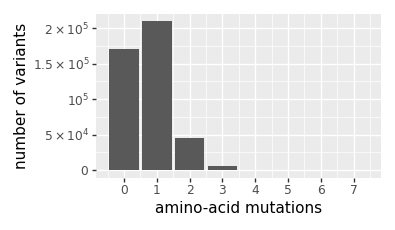

In [33]:
# distribution of amino-acid mutations per variant
p = variants.plotNumMutsHistogram(
    mut_type="aa",
    max_muts=8,
    widthscale=1.5,
    heightscale=1,
    libraries=variants.libraries,
    samples=None,
)
fig = p.draw(show=True)

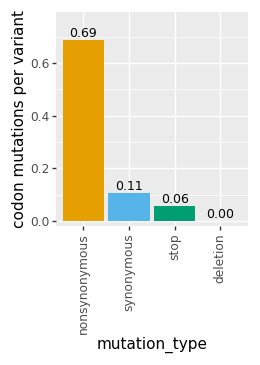

In [34]:
# average mutations per variant
p = variants.plotNumCodonMutsByType(
    variant_type="all",
    samples=None,
    libraries=variants.libraries,
    widthscale=1,
    heightscale=1.5,
    ylabel="codon mutations per variant",
)
fig = p.draw(show=True)

In [35]:
num_muts = variants.numCodonMutsByType(
    variant_type="all",
    samples=None,
    libraries=variants.libraries,
).assign(
    # remove categorical assignments to fix plotting issues
    mutation_type=lambda x: x["mutation_type"].tolist(),
    library=lambda x: x["library"].tolist(),
)

mut_type_order = (
    num_muts.sort_values("number", ascending=False)["mutation_type"].unique().tolist()
)

num_muts_chart = (
    alt.Chart(num_muts)
    .encode(
        x=alt.X("mutation_type", title=None, scale=alt.Scale(domain=mut_type_order)),
        y=alt.Y("number", title="codon mutations per variant"),
        color=alt.Color("mutation_type", legend=None),
        tooltip=["library", "mutation_type", alt.Tooltip("number", format=".2f")],
    )
    .mark_bar()
    .properties(width=alt.Step(50), height=200)
)

num_muts_chart

alt.Chart(...)

In [36]:
site_freqs = (variants
    .mutCounts(
        variant_type="all",
        mut_type="aa",
        samples=None,
        libraries=variants.libraries,
    )
    .query("count > 0")
    .assign(
        wildtype=lambda x: x["mutation"].str[0],
        mutant=lambda x: x["mutation"].str[-1],
        reference_site=lambda x: x["mutation"].str[1:-1],
        # remove categorical assignments to fix plotting issues
    )
    .assign(mutant=lambda x: x["mutant"] + "=" + x["count"].astype(str))
    .sort_values("count", ascending=False)
    .groupby(
        ["library", "reference_site", "wildtype"],
        observed=True,
        as_index=False,
    )
    .aggregate(
        count=pd.NamedAgg("count", "sum"),
        mutants=pd.NamedAgg("mutant", ", ".join),
    )
    .merge(
        variants.n_variants_df(
            samples=None, libraries=variants.libraries, primary_target_only=True
        )
        .rename(columns={"count": "n_variants"})
        .drop(columns="sample")
    )
    .assign(percent=lambda x: 100 * x["count"] / x["n_variants"])
    .drop(columns="n_variants")
    .astype({"reference_site": int})
    .sort_values("reference_site")
)
site_freqs

,library,reference_site,wildtype,count,mutants,percent
0,kpc,1,M,1984,"L=387, V=237, I=209, T=184, S=141, R=131, P=10...",0.457857
111,kpc,2,S,1210,"L=195, P=144, T=131, *=107, I=83, A=75, Y=59, ...",0.279237
217,kpc,3,L,927,"S=100, P=97, Q=88, R=83, *=71, T=57, I=50, A=4...",0.213928
228,kpc,4,Y,1417,"S=231, *=138, L=112, T=110, H=99, I=94, N=93, ...",0.327008
239,kpc,5,R,1260,"S=180, L=163, C=120, H=112, P=73, *=71, T=64, ...",0.290776
...,...,...,...,...,...,...
212,kpc,290,V,1692,"L=206, S=197, I=186, F=133, Y=107, R=93, T=91,...",0.390471
213,kpc,291,N,1905,"S=199, T=189, L=182, I=170, Y=109, P=105, K=10...",0.439626
214,kpc,292,G,1798,"L=216, S=183, R=178, T=123, P=117, V=116, I=11...",0.414933
215,kpc,293,Q,1940,"L=241, S=211, T=163, *=149, H=131, P=130, R=12...",0.447703


In [37]:
# make chart
zoom_brush = alt.selection_interval(
    encodings=["x"],
    mark=alt.BrushConfig(stroke="black", strokeWidth=2),
)

zoom_bar = (
    alt.Chart(site_freqs[["reference_site"]].drop_duplicates())
    .mark_rect(color="lightgrey")
    .encode(
        x=alt.X(
            "reference_site",
            title=None,
            scale=alt.Scale(nice=False, zero=False),
            sort=alt.SortField("reference_site"),
            axis=alt.Axis(labelOverlap=True),
        )
    )
    .add_params(zoom_brush)
    .properties(width=550, height=15, title="site zoom bar")
)

site_freqs_base = (
    alt.Chart()
    .encode(
        x=alt.X(
            "reference_site",
            scale=alt.Scale(nice=False, zero=False),
            sort=alt.SortField("reference_site"),
            axis=alt.Axis(labelOverlap=True),
        ),
        y=alt.Y("percent", title="% variants with mutation"),
        tooltip=[
            alt.Tooltip(c, format=".3g")
            if c in {"percent", "count", "n_variants"}
            else c
            for c in site_freqs.columns
        ],
    )
    .properties(height=125, width=550)
)

site_freqs_chart = (
    alt.layer(
        site_freqs_base.mark_point(filled=True),
        site_freqs_base.mark_line(size=0.5),
        data=site_freqs,
    )
    .facet(facet=alt.Facet("library", title=None), columns=1)
    .add_params(zoom_brush)
    .transform_filter(zoom_brush)
)

site_freqs_zoom_chart = (zoom_bar & site_freqs_chart).configure_axis(grid=False)

site_freqs_zoom_chart

/tmp/ipykernel_43571/1021207011.py:54: UserWarning: Automatically deduplicated selection parameter with identical configuration. If you want independent parameters, explicitly name them differently (e.g., name='param1', name='param2'). See https://github.com/vega/altair/issues/3891


alt.VConcatChart(...)

In [38]:
variants_df = pd.concat(
    [   
        variants.barcode_variant_df
        .assign(gene_mutation=gene_variants["gene_mutation"])
        .assign(mutation_type=lambda x: PacBioCCSsubprocess.classify_mutations_batch(x["gene_mutation"], x["aa_substitutions"]))
        .assign(barcode=lambda x: x["barcode"] + "TTAATTAAGG"),
        control_barcode
        .rename(columns={"name": "target", "protein_mutation": "aa_substitutions"})
        .assign(
            library="kpc",
            codon_substitutions="",
            n_codon_substitutions=0,
            n_aa_substitutions=0,
            mutation_type="No change",
            # variant call support for neut standards max of any gene variant
            variant_call_support=variants.barcode_variant_df["variant_call_support"].max(),
        )
    ]
)

variants_df["aa_substitutions"]=variants_df["aa_substitutions"].replace("", "WT")
variants_df.to_csv(os.path.join(current_dir, folder) + "/" + "KPC-2_PacBio_barcode-variant-table.csv", index=False)

In [39]:
variants_df

,target,library,barcode,variant_call_support,codon_substitutions,aa_substitutions,n_codon_substitutions,n_aa_substitutions,gene_mutation,mutation_type
0,gene,kpc,AAAAAAAAAGTCGACCGGATTTAATTAAGG,2,GAG274ACG,E274T,1,1,G820A A821C,Nonsynonymous mutation
1,gene,kpc,AAAAAAAACAAGAAAGTCAGTTAATTAAGG,1,CAC272ACT,H272T,1,1,C814A A815C C816T,Nonsynonymous mutation
2,gene,kpc,AAAAAAAACACATTTATGATTTAATTAAGG,3,GCT61GAT GAC91GAG GTG126ATG,A61D D91E V126M,3,3,C182A C273G G376A,Nonsynonymous mutation
3,gene,kpc,AAAAAAAACTTACAGGCGCGTTAATTAAGG,1,TGG15AAG,W15K,1,1,T43A G44A,Nonsynonymous mutation
4,gene,kpc,AAAAAAAATACATTTCGGATTTAATTAAGG,1,ATG1CTG,M1L,1,1,A1C,Nonsynonymous mutation
...,...,...,...,...,...,...,...,...,...,...
1,control,kpc,CCTTACAGATTTAATTAAGGAGGACCTTTG,401,,WT,0,0,WT2,No change
2,control,kpc,ATCCGGCAATTTAATTAAGGTTGGCTAACA,401,,WT,0,0,WT3,No change
3,control,kpc,GTATAGGTCCTTAATTAAGGCGATAACGCT,401,,nonfuntional,0,0,nonfuntional1,No change
4,control,kpc,TGAGACTCTGTTAATTAAGGCATAGCATGG,401,,nonfuntional,0,0,nonfuntional2,No change
